In [13]:
%load_ext autoreload
%autoreload 2
%reload_ext autoreload

import nest_asyncio
nest_asyncio.apply()

import plotly.express as px
import plotly.graph_objects as go
import plotly.io as pio
pio.renderers.default = "vscode"            

import matplotlib.pyplot as plt
import matplotlib.pylab as pylab
import matplotlib.dates as mdates
plt.style.use('ggplot')
params = {'legend.fontsize': 'x-large',
        'figure.figsize': (12, 8),
        'axes.labelsize': 'x-large',
        'axes.titlesize':'x-large',
        'xtick.labelsize':'x-large',
        'ytick.labelsize':'x-large'}
pylab.rcParams.update(params)

import pandas as pd
import numpy as np

import datetime
import pytz
NY_tz = pytz.timezone("America/New_York") 
CHI_tz = pytz.timezone("America/Chicago") 
UTC_tz = pytz.timezone("UTC") 

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [15]:
import rateslib as rl
import QuantLib as ql

from MDP.FixedRateBonds.FixedRateBondsMDP import FixedRateBondsMDP
from TB.FixedRateBondsTB import FixedRateBondsTB
from Query.FixedRateBonds.FixedRateBondQuery import FixedRateBondQuery 
from Query.FixedRateBonds.FixedRateBondStructure import FixedRateBondStructure, FixedRateBondStructureFunctionMap 
from Query.FixedRateBonds.FixedRateBondValue import FixedRateBondValue, FixedRateBondValueFunctionMap 

from MDP.IRSwaps.IRSwapsMDP import IRSwapsMDP
from TB.IRSwapsTB import IRSwapsTB
from Query.IRSwaps.IRSwapQuery import IRSwapQuery
from Query.IRSwaps.IRSwapStructure import IRSwapStructure
from Query.IRSwaps.IRSwapValue import IRSwapValue

from TB.TimeseriesBuilder import TimeseriesBuilder

# fmt: off
import Query.FixedRateBonds.adapter  # noqa: F401
# fmt: on

from utils.ql_utils import datetime_to_ql_date, ql_date_to_datetime 

In [ ]:
frb_mdp = FixedRateBondsMDP(source="USTS_PUBLICDOTCOM_WSJ_LIVE-QL")
frb_tb = FixedRateBondsTB(mdp=frb_mdp)

In [12]:
start = datetime.date(2025, 1, 1)
end = datetime.date(2025, 10, 8)
df = frb_tb.get_timeseries(
    start=start,
    end=end,
    queries=[FixedRateBondQuery(cusip="0550/0850/1150", value=FixedRateBondValue.YTM)],

    # ignore_cache=True,
    n_jobs=8,
)
df

PRICING FIXED-RATE BONDS.: 100%|██████████| 193/193 [02:14<00:00,  1.43it/s]


,0550/0850/1150 OUTRIGHT YTM
Date,
2025-01-02,1.9459
2025-01-03,2.4923
2025-01-06,2.3678
2025-01-07,2.6972
2025-01-08,2.0153
...,...
2025-10-02,3.7435
2025-10-03,3.8025
2025-10-06,3.8847


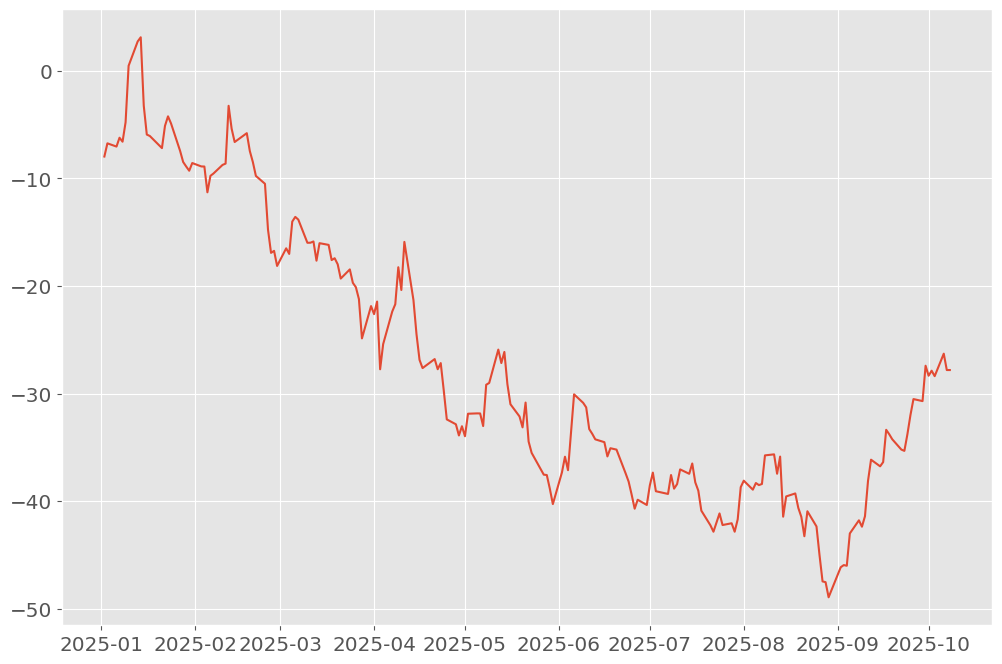

In [11]:
plt.plot(df)

In [ ]:
ql.OIS()

In [8]:
q = FixedRateBondQuery(cusip="o10/ct10", value=FixedRateBondValue.YTM, structure=FixedRateBondStructure.CURVE)
q.col_name()

'o10/ct10 CURVE YTM'

In [29]:
frb_mdp.get_pricer(dict(cusips=["0550/0850/1150"], timestamp="live"))

{'0550': QLFixedRateBondPricer(_ql_frb_id='USTS', _reference_date=datetime.date(2025, 10, 8), _issue_date=datetime.date(2020, 5, 15), _maturity_date=datetime.date(2050, 5, 15), _cpn=1.25, _notional=None, _clean_price=None, _ytm=np.float64(4.792), _meta_data={'record_date': datetime.date(2020, 5, 15), 'label': 'T 1 1/4 May 50', 'cusip': '912810SN9', 'oi': '30-Year', 'auction_date': datetime.date(2020, 5, 13), 'issue_date': datetime.date(2020, 5, 15), 'maturity_date': datetime.date(2050, 5, 15), 'cpn': 1.25, 'rank': 21, 'timestamp': Timestamp('2025-10-08 17:50:43+0000', tz='UTC')}),
 '0850': QLFixedRateBondPricer(_ql_frb_id='USTS', _reference_date=datetime.date(2025, 10, 8), _issue_date=datetime.date(2020, 8, 17), _maturity_date=datetime.date(2050, 8, 15), _cpn=1.375, _notional=None, _clean_price=None, _ytm=np.float64(4.827), _meta_data={'record_date': datetime.date(2020, 8, 17), 'label': 'T 1 3/8 Aug 50', 'cusip': '912810SP4', 'oi': '30-Year', 'auction_date': datetime.date(2020, 8, 13),

In [29]:
ust_pricers = frb_mdp._get_multi_pricers(cusips=["ct2/ct10"], timestamp="live")
ust_pricers

{'ct2': QLFixedRateBondPricer(_ql_frb_id='USTS', _reference_date=datetime.date(2025, 10, 8), _issue_date=datetime.date(2025, 9, 30), _maturity_date=datetime.date(2027, 9, 30), _cpn=3.5, _notional=None, _clean_price=None, _ytm=np.float64(3.572), _meta_data={'record_date': datetime.date(2025, 9, 30), 'label': 'T 3 1/2 Sep 27', 'cusip': '91282CPB1', 'oi': '2-Year', 'auction_date': datetime.date(2025, 9, 23), 'issue_date': datetime.date(2025, 9, 30), 'maturity_date': datetime.date(2027, 9, 30), 'cpn': 3.5, 'rank': 0, 'timestamp': Timestamp('2025-10-08 11:43:39+0000', tz='UTC')}),
 'ct10': QLFixedRateBondPricer(_ql_frb_id='USTS', _reference_date=datetime.date(2025, 10, 8), _issue_date=datetime.date(2025, 8, 15), _maturity_date=datetime.date(2035, 8, 15), _cpn=4.25, _notional=None, _clean_price=None, _ytm=np.float64(4.105), _meta_data={'record_date': datetime.date(2025, 8, 15), 'label': 'T 4 1/4 Aug 35', 'cusip': '91282CNT4', 'oi': '10-Year', 'auction_date': datetime.date(2025, 8, 6), 'issue

In [30]:
tenor = "ct5/ct10/ct30", FixedRateBondStructure.FLY 
timestamp = "live"

query = FixedRateBondQuery(cusip=tenor[0], structure=tenor[1], structure_kwargs={"bpv": 10_000})
pricer = frb_mdp._get_multi_pricers(cusips=[query.cusip], timestamp=timestamp)
pkg, rws = query.resolve_package(pricer_or_curve=pricer)
vmap = query.build_value_map(pricer_or_curve=pricer, package=pkg, risk_weights=rws)

In [31]:
pkg, rws

([<QuantLib.QuantLib.FixedRateBond; proxy of <Swig Object of type 'ext::shared_ptr< FixedRateBond > *' at 0x0000021FE5BD3690> >,
  <QuantLib.QuantLib.FixedRateBond; proxy of <Swig Object of type 'ext::shared_ptr< FixedRateBond > *' at 0x0000021FE4596100> >,
  <QuantLib.QuantLib.FixedRateBond; proxy of <Swig Object of type 'ext::shared_ptr< FixedRateBond > *' at 0x0000021FE4597DB0> >],
 [np.float64(-1.0), np.float64(2.0), np.float64(-1.0)])

In [32]:
# vmap.apply(FixedRateBondValue.NPV)
vmap.apply(FixedRateBondValue.YTM)
# vmap.apply(FixedRateBondValue.CLEAN_PRICE)

np.float64(-18.50000000000005)

In [64]:
pricer

{'91282CNT4': QLFixedRateBondPricer(_ql_frb_id='USTS', _reference_date=datetime.date(2025, 9, 10), _issue_date=datetime.date(2025, 8, 15), _maturity_date=datetime.date(2035, 8, 15), _cpn=4.25, _notional=None, _clean_price=None, _ytm=4.033482, _meta_data={'record_date': '2025-08-15', 'label': 'T 4 1/4 Aug 35', 'cusip': '91282CNT4', 'oi': '10-Year', 'auction_date': '2025-08-06', 'issue_date': '2025-08-15', 'maturity_date': '2035-08-15', 'cpn': 4.25, 'rank': 0})}